In [1]:
import numpy as np
import pandas as pd
import sys
sys.path.append('/fast/pmayilvahanan/post_training/dapo/verl/notebooks')
from utils import collate_experiment_results
import os
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
base_results_dir = '/fast/pmayilvahanan/post_training/verl_checkpoints/self_distillation_neurips/Qwen'

In [3]:
results = collate_experiment_results(base_results_dir)

In [4]:
results.columns

Index(['exp_name', 'training_type', 'step', 'model', 'lr', 'training_data',
       'epochs', 'total_training_steps', 'train_batch_size',
       'micro_batch_size', 'val/HuggingFaceH4/aime_2024/pass@1/mean@8',
       'val/HuggingFaceH4/aime_2024/pass@8/mean',
       'val/math-ai/aime25/pass@1/mean@8', 'val/math-ai/aime25/pass@8/mean',
       'val/math-ai/amc23/pass@1/mean@8', 'val/math-ai/amc23/pass@8/mean',
       'val/math-ai/gpqa/pass@1/mean@8', 'val/math-ai/gpqa/pass@8/mean',
       'val/math-ai/minervamath/pass@1/mean@8',
       'val/math-ai/minervamath/pass@8/mean',
       'val/math-ai/olympiadbench/pass@1/mean@8',
       'val/math-ai/olympiadbench/pass@8/mean',
       'val/simplescaling/openaimath/pass@1/mean@8',
       'val/simplescaling/openaimath/pass@8/mean'],
      dtype='object')

In [5]:
columns_pass1 = ['val/math-ai/aime25/pass@1/mean@8',
                 'val/math-ai/amc23/pass@1/mean@8',
                 'val/math-ai/minervamath/pass@1/mean@8',
                 'val/math-ai/olympiadbench/pass@1/mean@8',
                 'val/HuggingFaceH4/aime_2024/pass@1/mean@8',
                 'val/math-ai/gpqa/pass@1/mean@8',
                 ]
columns_pass8 = ['val/math-ai/aime25/pass@8/mean',
                 'val/math-ai/amc23/pass@8/mean',
                 'val/math-ai/minervamath/pass@8/mean',
                 'val/math-ai/olympiadbench/pass@8/mean',
                 'val/HuggingFaceH4/aime_2024/pass@8/mean',
                 'val/math-ai/gpqa/pass@8/mean',
                 ]

# Create OOD metrics as the mean of the columns
results['OOD/pass@1/mean@8'] = results[columns_pass1].mean(axis=1)
results['OOD/pass@8/mean'] = results[columns_pass8].mean(axis=1)

columns_pass1_wo_aime = ['val/math-ai/amc23/pass@1/mean@8',
                 'val/math-ai/minervamath/pass@1/mean@8',
                 'val/math-ai/olympiadbench/pass@1/mean@8',
                 'val/math-ai/gpqa/pass@1/mean@8',
                 ]
columns_pass8_wo_aime = ['val/math-ai/amc23/pass@8/mean',
                 'val/math-ai/minervamath/pass@8/mean',
                 'val/math-ai/olympiadbench/pass@8/mean',
                 'val/math-ai/gpqa/pass@8/mean',
                 ]

results['OOD_wo_aime/pass@1/mean@8'] = results[columns_pass1_wo_aime].mean(axis=1)
results['OOD_wo_aime/pass@8/mean'] = results[columns_pass8_wo_aime].mean(axis=1)


In [6]:
results_rl = results[results['training_type'] == 'RL']
results_sft = results[results['training_type'] == 'SFT']

In [172]:
results_rl

,exp_name,training_type,step,model,lr,training_data,epochs,total_training_steps,train_batch_size,micro_batch_size,...,val/math-ai/minervamath/pass@1/mean@8,val/math-ai/minervamath/pass@8/mean,val/math-ai/olympiadbench/pass@1/mean@8,val/math-ai/olympiadbench/pass@8/mean,val/simplescaling/openaimath/pass@1/mean@8,val/simplescaling/openaimath/pass@8/mean,OOD/pass@1/mean@8,OOD/pass@8/mean,OOD_wo_aime/pass@1/mean@8,OOD_wo_aime/pass@8/mean
72,Qwen2.5-3B_openai_math_n_8_bsz_512_epochs_5_kl...,RL,0.0,Qwen/Qwen2.5-3B,0.000001,train,5,35,512,128,...,0.106158,0.338235,0.102593,0.324444,0.35100,0.728,0.063816,0.232543,0.093641,0.332147
73,Qwen2.5-3B_openai_math_n_8_bsz_512_epochs_5_kl...,RL,3.0,Qwen/Qwen2.5-3B,0.000001,train,5,35,512,128,...,0.121783,0.352941,0.109630,0.343704,0.34850,0.740,0.066831,0.219601,0.097121,0.304401
74,Qwen2.5-3B_openai_math_n_8_bsz_512_epochs_5_kl...,RL,6.0,Qwen/Qwen2.5-3B,0.000001,train,5,35,512,128,...,0.125460,0.371324,0.133704,0.376296,0.39400,0.764,0.073739,0.239713,0.107483,0.334569
75,Qwen2.5-3B_openai_math_n_8_bsz_512_epochs_5_kl...,RL,9.0,Qwen/Qwen2.5-3B,0.000001,train,5,35,512,128,...,0.178309,0.375000,0.178519,0.400000,0.48750,0.788,0.104047,0.274874,0.151904,0.378977
76,Qwen2.5-3B_openai_math_n_8_bsz_512_epochs_5_kl...,RL,12.0,Qwen/Qwen2.5-3B,0.000001,train,5,35,512,128,...,0.198989,0.411765,0.207778,0.440000,0.53350,0.802,0.121340,0.289898,0.171594,0.393181
77,Qwen2.5-3B_openai_math_n_8_bsz_512_epochs_5_kl...,RL,12.0,Qwen/Qwen2.5-3B,0.000001,train,5,35,512,128,...,0.194853,0.408088,0.198704,0.426667,0.54150,0.824,0.125183,0.306255,0.174234,0.392717
78,Qwen2.5-3B_openai_math_n_8_bsz_512_epochs_5_kl...,RL,15.0,Qwen/Qwen2.5-3B,0.000001,train,5,35,512,128,...,0.197610,0.404412,0.217963,0.445926,0.57225,0.828,0.138954,0.309400,0.194889,0.414100
79,Qwen2.5-3B_openai_math_n_8_bsz_512_epochs_5_kl...,RL,15.0,Qwen/Qwen2.5-3B,0.000001,train,5,35,512,128,...,0.202665,0.422794,0.215556,0.435556,0.56625,0.822,0.126580,0.304338,0.173203,0.389840
80,Qwen2.5-3B_openai_math_n_8_bsz_512_epochs_5_kl...,RL,18.0,Qwen/Qwen2.5-3B,0.000001,train,5,35,512,128,...,0.209099,0.400735,0.221667,0.450370,0.57575,0.828,0.129165,0.289789,0.185414,0.393016
81,Qwen2.5-3B_openai_math_n_8_bsz_512_epochs_5_kl...,RL,21.0,Qwen/Qwen2.5-3B,0.000001,train,5,35,512,128,...,0.219669,0.441176,0.242222,0.484444,0.59025,0.840,0.143023,0.319969,0.200992,0.421620


## Analyzing RL results

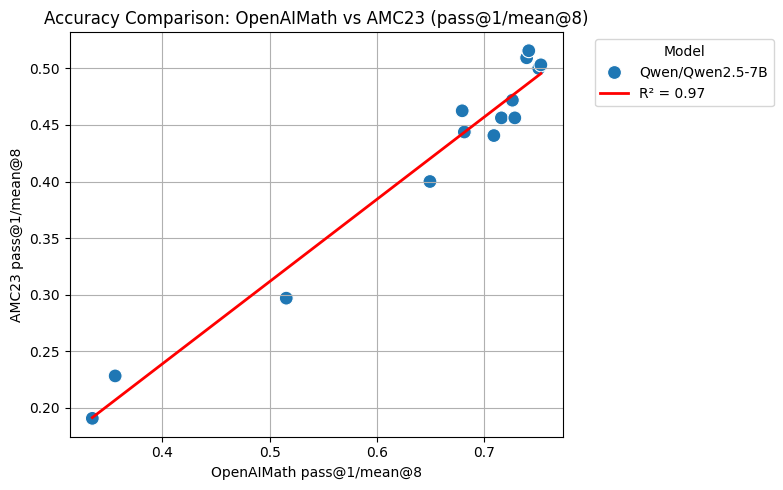

In [176]:
plt.figure(figsize=(8, 5))
# Create the scatter plot
sns.scatterplot(
    data=results_rl[results_rl['model'] == 'Qwen/Qwen2.5-7B'],
    x='val/simplescaling/openaimath/pass@1/mean@8',
    y='val/math-ai/amc23/pass@1/mean@8',
    hue='model',  # Different colors for models
    style='model', # Different markers for models
    s=100         # Marker size
)

# Get data for the linear regression
data = results_rl[results_rl['model'] == 'Qwen/Qwen2.5-7B']
x_data = data['val/simplescaling/openaimath/pass@1/mean@8'].astype(float)
y_data = data['val/math-ai/amc23/pass@1/mean@8'].astype(float)
valid_indices = x_data.notna() & y_data.notna()

# Compute linear regression and R-squared
if sum(valid_indices) > 1:
    x_fit = x_data[valid_indices]
    y_fit = y_data[valid_indices]
    m, b = np.polyfit(x_fit, y_fit, 1)
    
    # Calculate R-squared
    correlation = np.corrcoef(x_fit, y_fit)[0, 1]
    r_squared = correlation**2
    
    # Plot the regression line
    x_range = np.array([x_fit.min(), x_fit.max()])
    plt.plot(x_range, m * x_range + b, 'r-', linewidth=2, 
             label=f'R² = {r_squared:.2f}')
    plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Accuracy Comparison: OpenAIMath vs AMC23 (pass@1/mean@8)')
plt.xlabel('OpenAIMath pass@1/mean@8')
plt.ylabel('AMC23 pass@1/mean@8')
plt.grid(True)
plt.tight_layout()
plt.show()

In [178]:
results_rl['val/simplescaling/openaimath/pass@1/mean@8'].min()

0.030750000849366188

/tmp/ipykernel_3798385/210734199.py:81: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0, 0, 0.75, 1]) # rect=[left, bottom, right, top]


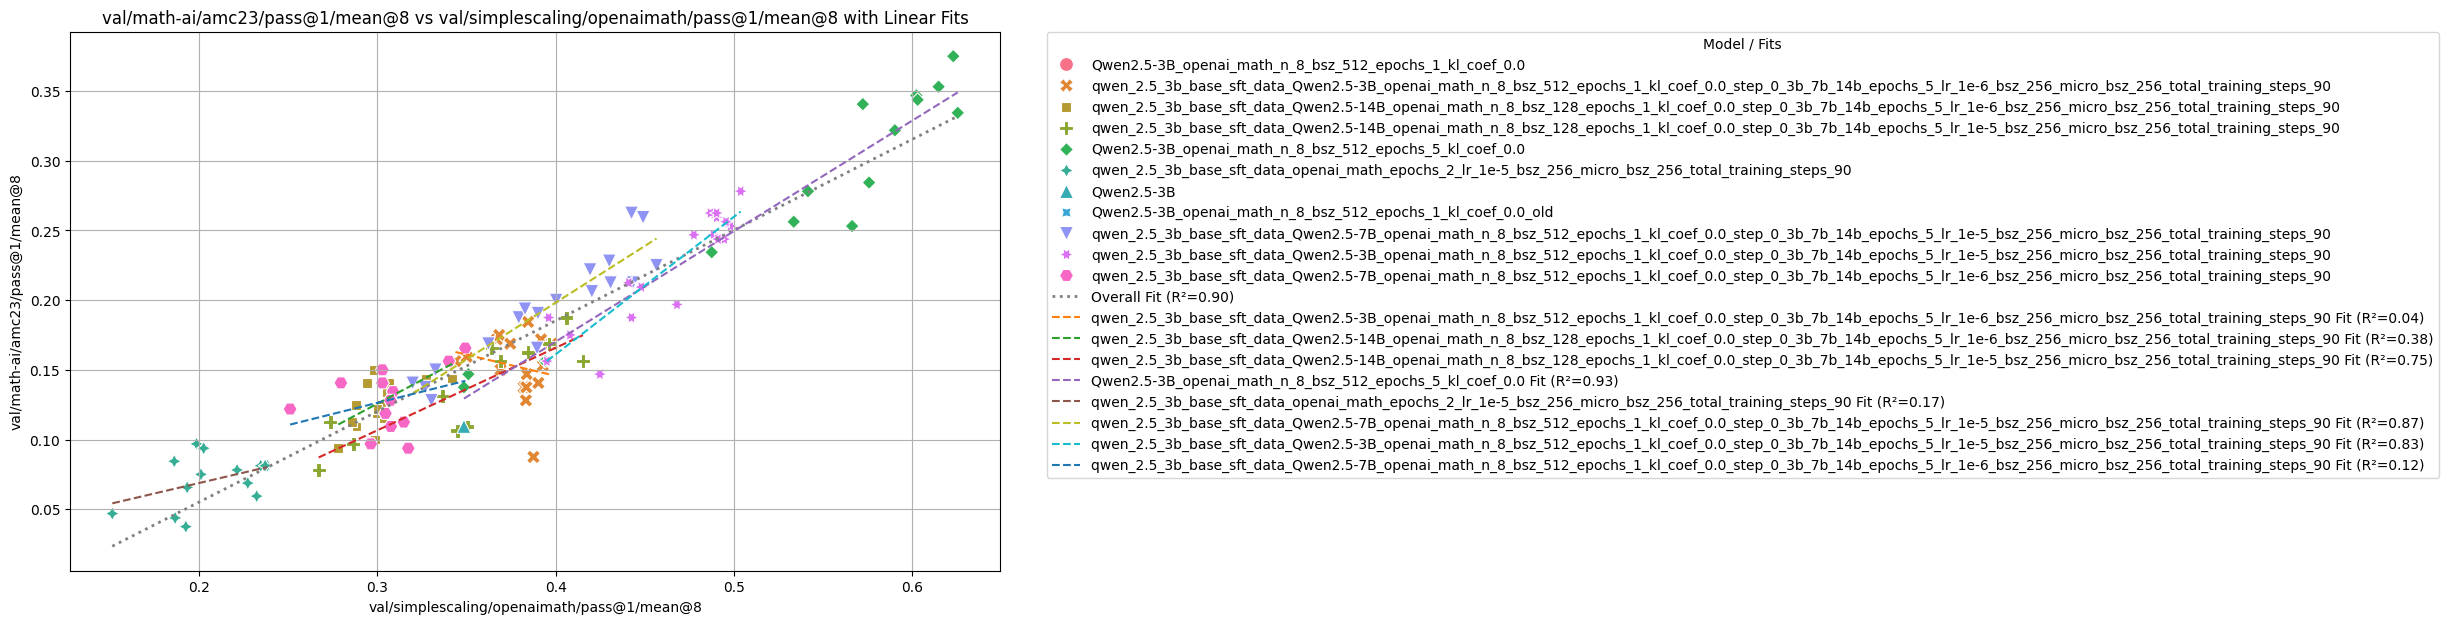

In [20]:
x_metric = 'val/simplescaling/openaimath/pass@1/mean@8'
y_metric = 'val/math-ai/amc23/pass@1/mean@8'
model_column = 'exp_name'

results_rl = results[results['model']=='Qwen/Qwen2.5-3B']

plt.figure(figsize=(12, 7)) # Adjusted figure size for a better legend layout

# 1. Scatter plot
ax = sns.scatterplot(
    data=results_rl,
    x=x_metric,
    y=y_metric,
    hue=model_column,
    style=model_column,
    s=100
)

# Prepare data for fitting (ensure numeric and no NaNs for fitting)
# Convert to float and drop NaNs specifically for the metrics being plotted
x_data_all_plotting = results_rl[x_metric].astype(float)
y_data_all_plotting = results_rl[y_metric].astype(float)
valid_indices_all = x_data_all_plotting.notna() & y_data_all_plotting.notna()

x_data_all_fit = x_data_all_plotting[valid_indices_all]
y_data_all_fit = y_data_all_plotting[valid_indices_all]

# 2. Overall fit
if len(x_data_all_fit) > 1:
    m_all, b_all = np.polyfit(x_data_all_fit, y_data_all_fit, 1)
    
    # Calculate R-squared for the overall fit
    correlation_matrix_all = np.corrcoef(x_data_all_fit, y_data_all_fit)
    r_all = correlation_matrix_all[0, 1]
    r_squared_all = r_all**2
    
    # Create a range for plotting the line smoothly
    x_fit_range_all = np.array([x_data_all_fit.min(), x_data_all_fit.max()])
    plt.plot(x_fit_range_all, m_all * x_fit_range_all + b_all, color='grey', linestyle=':', linewidth=2, label=f'Overall Fit (R²={r_squared_all:.2f})')

# 3. Individual model fits
models = results_rl[model_column].unique()
# Get the palette used by seaborn for hue to match colors
# Note: This relies on the order of models being the same as how seaborn processes them.
# If colors don't match, you might need to manually map model_name to colors.
palette = sns.color_palette(n_colors=len(models))

for i, model_name in enumerate(models):
    model_data = results_rl[results_rl[model_column] == model_name]
    
    x_data_model_plotting = model_data[x_metric].astype(float)
    y_data_model_plotting = model_data[y_metric].astype(float)
    valid_indices_model = x_data_model_plotting.notna() & y_data_model_plotting.notna()

    x_data_model_fit = x_data_model_plotting[valid_indices_model]
    y_data_model_fit = y_data_model_plotting[valid_indices_model]

    if len(x_data_model_fit) > 1:
        m, b = np.polyfit(x_data_model_fit, y_data_model_fit, 1)
        
        # Calculate R-squared for the model fit
        correlation_matrix_model = np.corrcoef(x_data_model_fit, y_data_model_fit)
        r_model = correlation_matrix_model[0, 1]
        r_squared_model = r_model**2
        
        line_color = palette[i % len(palette)] # Cycle through palette colors
        
        x_fit_range_model = np.array([x_data_model_fit.min(), x_data_model_fit.max()])
        # The scatter plot already created legend entries for models based on 'hue'.
        # We add the R-squared to a new label for the line.
        # To avoid duplicate model names in legend, we can make line labels more specific.
        plt.plot(x_fit_range_model, m * x_fit_range_model + b, linestyle='--', linewidth=1.5, label=f'{model_name} Fit (R²={r_squared_model:.2f})', color=line_color)

plt.title(f'{y_metric} vs {x_metric} with Linear Fits')
plt.xlabel(x_metric)
plt.ylabel(y_metric)
# Adjust legend to be outside the plot for clarity
plt.legend(title='Model / Fits', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
# Adjust layout to make space for the legend outside the plot area
plt.tight_layout(rect=[0, 0, 0.75, 1]) # rect=[left, bottom, right, top]
plt.show()

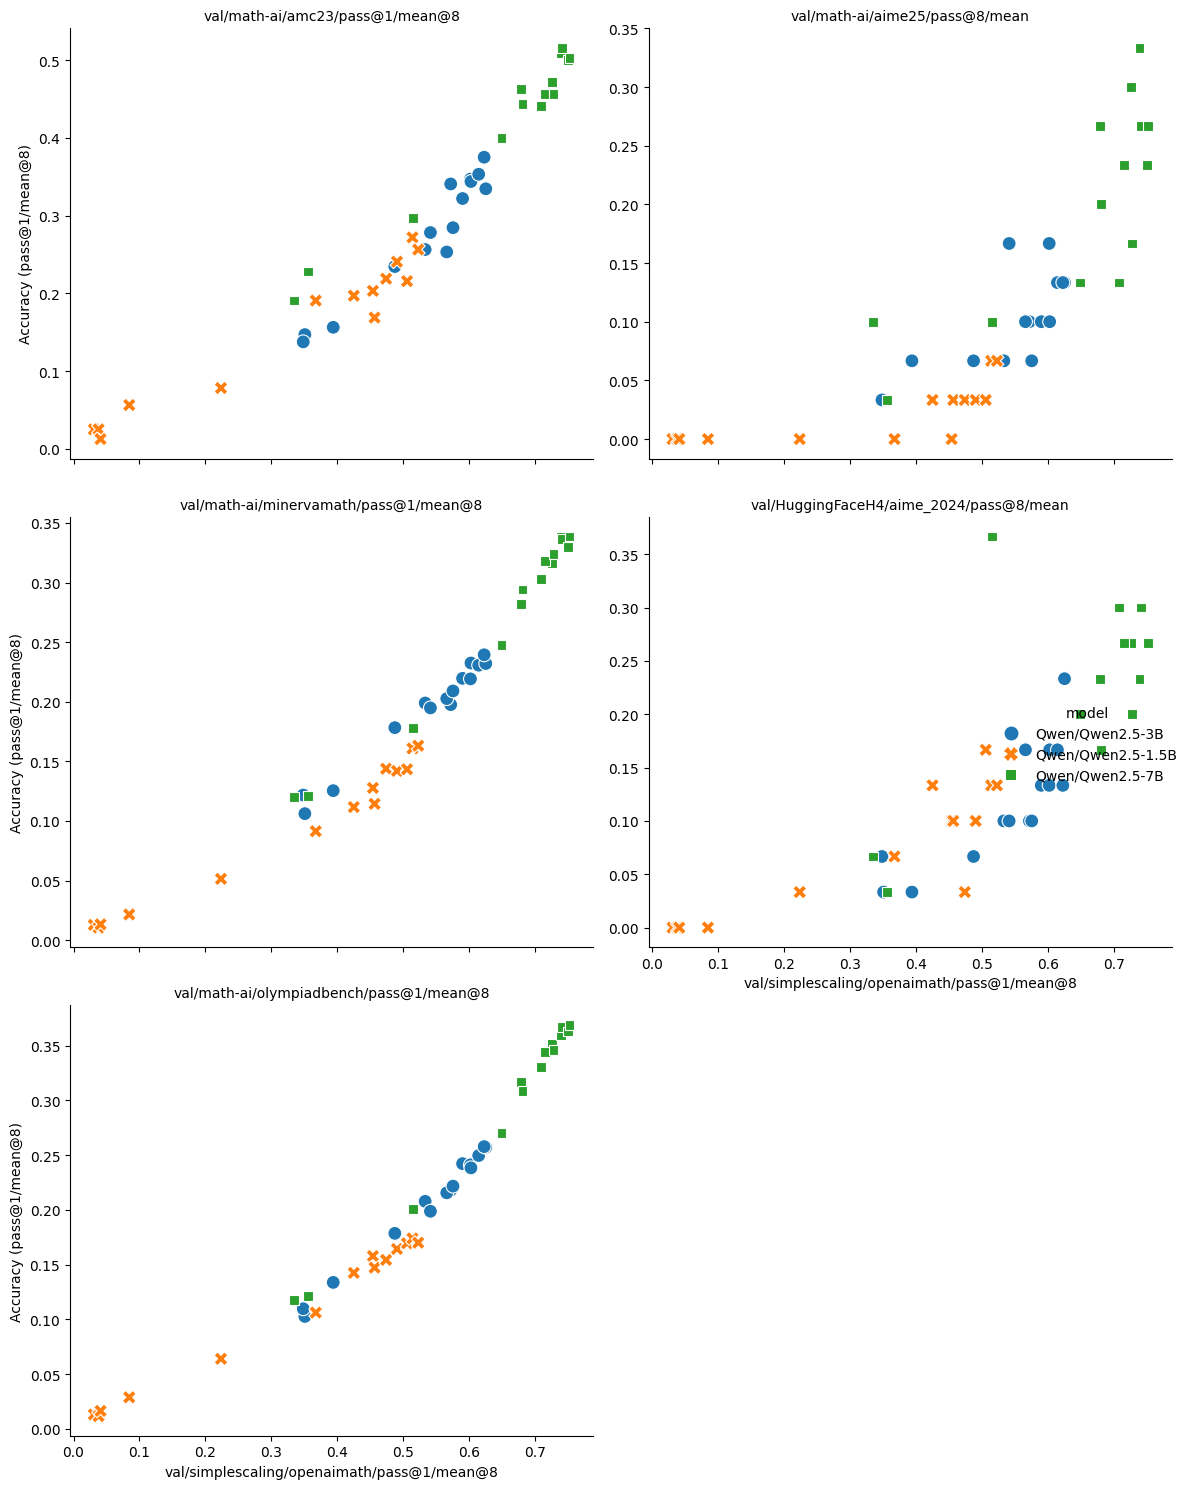

In [18]:
# Define your x metric and the list of y metrics
x_metric = 'val/simplescaling/openaimath/pass@1/mean@8'
y_metrics_list = [
    'val/math-ai/amc23/pass@1/mean@8',
    'val/math-ai/aime25/pass@8/mean',
    'val/math-ai/minervamath/pass@1/mean@8',
    'val/HuggingFaceH4/aime_2024/pass@8/mean',
    'val/math-ai/olympiadbench/pass@1/mean@8',
]
model_column = 'model' # or whatever your model identifier column is

# Melt the DataFrame to long format for easier plotting with Seaborn
id_vars_for_melt = [model_column, x_metric, 'exp_name', 'step'] # Add other identifiers if needed
# Ensure all y_metrics are actually in the dataframe
valid_y_metrics = [col for col in y_metrics_list if col in results_rl.columns]
if not valid_y_metrics:
    print(f"None of the specified y_metrics are in the DataFrame. Available columns: {results_rl.columns.tolist()}")
else:
    df_melted = results_rl.melt(
        id_vars=id_vars_for_melt,
        value_vars=valid_y_metrics,
        var_name='Y_Metric_Type',
        value_name='Y_Metric_Value'
    )

    # Create the plot
    g = sns.relplot(
        data=df_melted,
        x=x_metric,
        y='Y_Metric_Value',
        hue=model_column,
        style=model_column,
        col='Y_Metric_Type', # Creates a separate column for each Y metric
        kind='scatter',
        s=100,
        col_wrap=2,        # Wrap columns if you have many Y metrics
        facet_kws={'sharey': False, 'sharex': True} # Adjust sharing of axes as needed
    )

    g.set_titles("{col_name}") # Set titles for each subplot
    g.set_xlabels(f"{x_metric}")
    g.set_ylabels("Accuracy (pass@1/mean@8)")
    plt.tight_layout()
    plt.show()

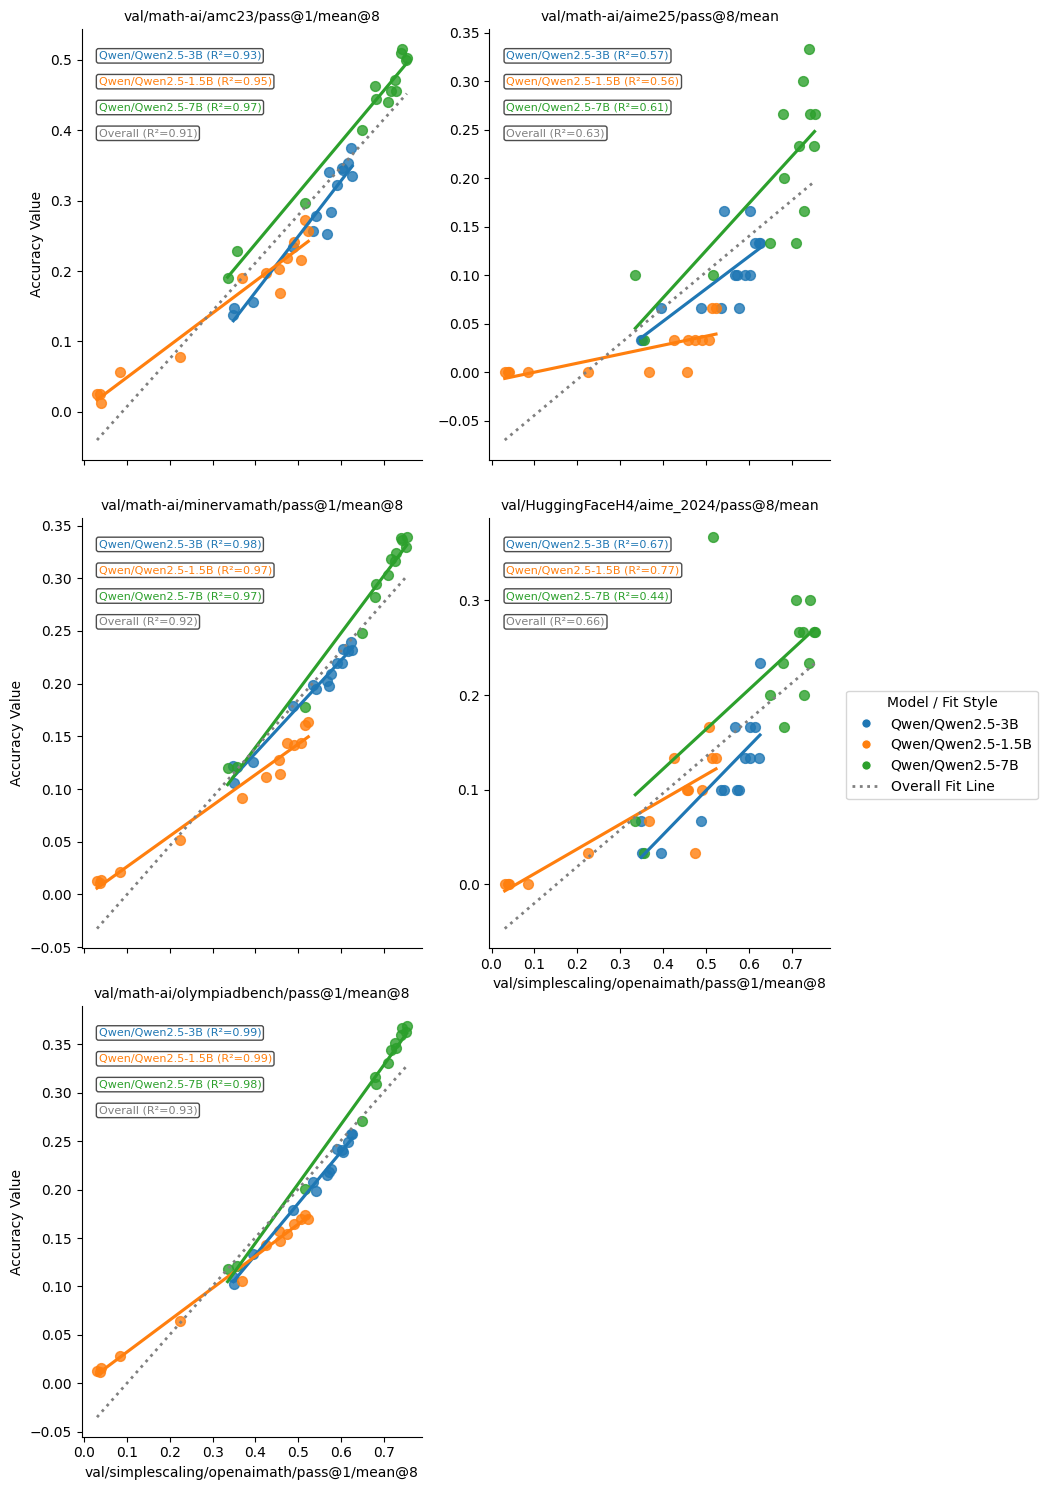

In [19]:
# Melt the DataFrame (ensure 'id_vars_for_melt' includes all necessary identifiers)
id_vars_for_melt = [model_column, x_metric, 'exp_name', 'step']
valid_y_metrics = [col for col in y_metrics_list if col in results_rl.columns]

if not valid_y_metrics:
    print(f"None of the specified y_metrics are in the DataFrame. Available columns: {results_rl.columns.tolist()}")
else:
    df_melted = results_rl.melt(
        id_vars=id_vars_for_melt,
        value_vars=valid_y_metrics,
        var_name='Y_Metric_Type',
        value_name='Y_Metric_Value'
    )

    # Create the faceted plot with lmplot for individual model fits
    g = sns.lmplot(
        data=df_melted,
        x=x_metric,
        y='Y_Metric_Value',
        hue=model_column,
        col='Y_Metric_Type',
        col_wrap=2, # Adjust as needed
        facet_kws={'sharey': False, 'sharex': True},
        ci=None,    # No confidence interval for cleaner plot
        scatter_kws={'s': 50},
        legend=False # Will handle legend/annotations manually
    )

    # Add R-squared annotations and overall fit line to each facet
    for i, ax_col_name in enumerate(g.col_names): # g.col_names gives the Y_Metric_Type for each column of facets
        # Handle cases where col_wrap might create more axes than there are Y_Metric_Types
        # This loop assumes g.axes is a 1D array if col_wrap is used, or 2D if not.
        # We iterate using g.col_names to map to the correct data.
        
        axes_in_col = g.axes_dict.get(ax_col_name, None) # For newer seaborn versions, axes_dict is useful
        if axes_in_col is None and len(g.axes.shape) == 1 and i < len(g.axes): # Fallback for older or 1D axes array
             axes_in_col = g.axes[i]
        elif axes_in_col is None:
            continue


        ax = axes_in_col # Current axis for the facet

        current_y_metric_type = ax_col_name
        
        # Filter original DataFrame for overall fit on this facet
        facet_data_orig_x = results_rl[x_metric].dropna().astype(float)
        facet_data_orig_y = results_rl[current_y_metric_type].dropna().astype(float)
        
        valid_indices_facet_all = facet_data_orig_x.index.intersection(facet_data_orig_y.index)
        x_all_facet = facet_data_orig_x[valid_indices_facet_all]
        y_all_facet = facet_data_orig_y[valid_indices_facet_all]

        if len(x_all_facet) > 1:
            m_overall_facet, b_overall_facet = np.polyfit(x_all_facet, y_all_facet, 1)
            r_overall_facet = np.corrcoef(x_all_facet, y_all_facet)[0, 1]
            r2_overall_facet = r_overall_facet**2
            
            x_fit_range_overall = np.array([x_all_facet.min(), x_all_facet.max()])
            ax.plot(x_fit_range_overall, m_overall_facet * x_fit_range_overall + b_overall_facet, 
                    color='grey', linestyle=':', linewidth=2, label=f'Overall (R²={r2_overall_facet:.2f})')

        # Annotate R-squared for individual models (lmplot plots the lines)
        models_on_facet = df_melted[df_melted['Y_Metric_Type'] == current_y_metric_type][model_column].unique()
        text_y_pos = 0.95 # Starting Y position for text annotation on the axes
        palette_lm = sns.color_palette(n_colors=len(models_on_facet)) # Palette for model colors

        for j, model_name in enumerate(models_on_facet):
            # Filter original DataFrame for this model and Y_Metric_Type
            model_specific_data = results_rl[results_rl[model_column] == model_name]
            model_x_facet = model_specific_data[x_metric].dropna().astype(float)
            model_y_facet = model_specific_data[current_y_metric_type].dropna().astype(float)

            valid_indices_model_facet = model_x_facet.index.intersection(model_y_facet.index)
            x_model_valid_facet = model_x_facet[valid_indices_model_facet]
            y_model_valid_facet = model_y_facet[valid_indices_model_facet]

            if len(x_model_valid_facet) > 1:
                r_model_facet = np.corrcoef(x_model_valid_facet, y_model_valid_facet)[0, 1]
                r2_model_facet = r_model_facet**2
                # lmplot hue colors are usually from sns.color_palette()
                model_color = palette_lm[j % len(palette_lm)] 
                ax.text(0.05, text_y_pos, f'{model_name} (R²={r2_model_facet:.2f})', 
                        transform=ax.transAxes, fontsize=8, color=model_color, 
                        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
                text_y_pos -= 0.06 # Adjust for next text line
        
        # Annotate Overall R-squared on the plot as well
        if len(x_all_facet) > 1:
             ax.text(0.05, text_y_pos, f'Overall (R²={r2_overall_facet:.2f})', 
                     transform=ax.transAxes, fontsize=8, color='grey', verticalalignment='top',
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

    g.set_titles("{col_name}")
    g.set_xlabels(f"{x_metric}")
    g.set_ylabels("Accuracy Value")
    
    # Add a single combined legend for model hues (markers) and the overall fit line style
    handles = []
    labels = []
    
    # Get model hue handles from lmplot (it creates them internally)
    # We can create proxy artists for the legend
    unique_models_for_legend = df_melted[model_column].unique()
    palette_for_legend = sns.color_palette(n_colors=len(unique_models_for_legend))
    for k, model_name_leg in enumerate(unique_models_for_legend):
        handles.append(plt.Line2D([0], [0], marker='o', color='w', 
                                  markerfacecolor=palette_for_legend[k % len(palette_for_legend)], 
                                  markersize=7, label=model_name_leg))
        labels.append(model_name_leg)

    # Add overall fit line style
    if any(len(results_rl[x_metric].dropna()) > 1 and len(results_rl[ym].dropna()) > 1 for ym in valid_y_metrics): # Check if any overall fit was made
        handles.append(plt.Line2D([0], [0], color='grey', linestyle=':', linewidth=2))
        labels.append('Overall Fit Line')

    if handles:
        g.fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.05, 0.5), title="Model / Fit Style")

    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout for legend
    plt.show()

## Analyze SFT results

In [7]:
results_sft_7b = results_sft[results_sft['model'] == 'Qwen/Qwen2.5-7B']
results_sft_3b = results_sft[results_sft['model'] == 'Qwen/Qwen2.5-3B']

In [40]:
results_sft_3b

,exp_name,training_type,step,model,lr,training_data,epochs,total_training_steps,train_batch_size,micro_batch_size,...,val/math-ai/gpqa/pass@1/mean@8,val/math-ai/gpqa/pass@8/mean,val/math-ai/minervamath/pass@1/mean@8,val/math-ai/minervamath/pass@8/mean,val/math-ai/olympiadbench/pass@1/mean@8,val/math-ai/olympiadbench/pass@8/mean,val/simplescaling/openaimath/pass@1/mean@8,val/simplescaling/openaimath/pass@8/mean,OOD/pass@1/mean@8,OOD/pass@8/mean
21,qwen_2.5_3b_base_sft_data_Qwen2.5-3B_openai_ma...,SFT,6.0,Qwen/Qwen2.5-3B,0.000001,train_common_indices_3_7_14,5,90,64,256,...,0.010732,0.080808,0.109375,0.334559,0.112037,0.362963,0.34375,0.718,0.066816,0.238055
22,qwen_2.5_3b_base_sft_data_Qwen2.5-3B_openai_ma...,SFT,12.0,Qwen/Qwen2.5-3B,0.000001,train_common_indices_3_7_14,5,90,64,256,...,0.013258,0.075758,0.122702,0.334559,0.112222,0.355556,0.36700,0.754,0.070010,0.219312
23,qwen_2.5_3b_base_sft_data_Qwen2.5-3B_openai_ma...,SFT,18.0,Qwen/Qwen2.5-3B,0.000001,train_common_indices_3_7_14,5,90,64,256,...,0.018939,0.090909,0.130055,0.323529,0.121111,0.370370,0.39775,0.746,0.078004,0.251635
24,qwen_2.5_3b_base_sft_data_Qwen2.5-3B_openai_ma...,SFT,20.0,Qwen/Qwen2.5-3B,0.000001,train_common_indices_3_7_14,5,90,64,256,...,0.011364,0.055556,0.113971,0.338235,0.119815,0.354074,0.36900,0.732,0.066553,0.226033
25,qwen_2.5_3b_base_sft_data_Qwen2.5-3B_openai_ma...,SFT,24.0,Qwen/Qwen2.5-3B,0.000001,train_common_indices_3_7_14,5,90,64,256,...,0.015783,0.070707,0.114430,0.356618,0.106481,0.352593,0.35000,0.718,0.067400,0.227208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,qwen_2.5_3b_base_sft_data_Qwen2.5-7B_openai_ma...,SFT,42.0,Qwen/Qwen2.5-3B,0.000001,train_common_indices_3_7_14,5,90,64,256,...,0.012626,0.060606,0.099265,0.334559,0.088704,0.311111,0.30450,0.696,0.053919,0.185768
232,qwen_2.5_3b_base_sft_data_Qwen2.5-7B_openai_ma...,SFT,48.0,Qwen/Qwen2.5-3B,0.000001,train_common_indices_3_7_14,5,90,64,256,...,0.015783,0.090909,0.093750,0.294118,0.087963,0.302222,0.30725,0.688,0.056353,0.206208
233,qwen_2.5_3b_base_sft_data_Qwen2.5-7B_openai_ma...,SFT,54.0,Qwen/Qwen2.5-3B,0.000001,train_common_indices_3_7_14,5,90,64,256,...,0.018939,0.101010,0.091452,0.341912,0.084259,0.309630,0.29625,0.680,0.049977,0.199036
234,qwen_2.5_3b_base_sft_data_Qwen2.5-7B_openai_ma...,SFT,60.0,Qwen/Qwen2.5-3B,0.000001,train_common_indices_3_7_14,5,90,64,256,...,0.015152,0.065657,0.097886,0.312500,0.091296,0.333333,0.30275,0.700,0.058882,0.233859


## Analyze best results

In [8]:
# Get the best performing row for each experiment based on OpenAI Math pass@1 score
results_new = results.dropna()
best_results = results_new.loc[results_new.groupby('exp_name')['val/simplescaling/openaimath/pass@1/mean@8'].idxmax()]

# Select only the relevant columns for display
best_results_display = best_results[['exp_name', 'model', 'training_type', 'step', 'training_data', 'lr',
                                    'val/simplescaling/openaimath/pass@1/mean@8', 
                                    'OOD/pass@1/mean@8', 'OOD_wo_aime/pass@1/mean@8',
                                    'OOD/pass@8/mean', 'OOD_wo_aime/pass@8/mean']]

# Sort by the OpenAI Math performance in descending order
best_results_display = best_results_display.sort_values(
    by='val/simplescaling/openaimath/pass@1/mean@8', 
    ascending=False
)

# Display the results
print("Best performing checkpoint for each experiment:")
#best_results_display


Best performing checkpoint for each experiment:


In [179]:
best_results_display[best_results_display['model'] == 'Qwen/Qwen2.5-7B']

,exp_name,model,training_type,step,training_data,lr,val/simplescaling/openaimath/pass@1/mean@8,OOD/pass@1/mean@8,OOD_wo_aime/pass@1/mean@8,OOD/pass@8/mean,OOD_wo_aime/pass@8/mean
237,Qwen2.5-7B_openai_math_n_8_bsz_512_epochs_5_kl...,Qwen/Qwen2.5-7B,RL,35.0,train,0.000001,0.75250,0.241031,0.314672,0.427479,0.507886
20,qwen_2.5_7b_base_sft_data_Qwen2.5-14B_openai_m...,Qwen/Qwen2.5-7B,SFT,84.0,train_common_indices_7_14,0.000010,0.55350,0.145185,0.197986,0.344278,0.433084
125,qwen_2.5_7b_base_sft_data_Qwen2.5-7B_openai_ma...,Qwen/Qwen2.5-7B,SFT,12.0,train_common_indices_7_14,0.000010,0.54075,0.147369,0.198137,0.354831,0.432247
140,qwen_2.5_7b_base_sft_data_Qwen2.5-7B_openai_ma...,Qwen/Qwen2.5-7B,SFT,18.0,train_common_indices_7_14,0.000001,0.47700,0.134936,0.180529,0.336972,0.430458
89,qwen_2.5_7b_base_sft_data_Qwen2.5-14B_openai_m...,Qwen/Qwen2.5-7B,SFT,12.0,train_common_indices_7_14,0.000001,0.41525,0.086024,0.125911,0.279096,0.393644
3,Qwen2.5-7B_dapo_math_17k_n_8_bsz_512_epochs_10...,Qwen/Qwen2.5-7B,Base,3.0,train,0.000001,0.34950,0.077194,0.107458,0.250976,0.326463
187,qwen_2.5_7b_base_sft_data_openai_math_epochs_2...,Qwen/Qwen2.5-7B,SFT,66.0,train,0.000010,0.34825,0.057415,0.081956,0.204830,0.282245
157,Qwen2.5-7B,Qwen/Qwen2.5-7B,Base,0.0,train,0.000001,0.32225,0.075259,0.104555,0.285373,0.378060


In [13]:
print(best_results_display[best_results_display['model'] == 'Qwen/Qwen2.5-3B']['exp_name'])

85     Qwen2.5-3B_openai_math_n_8_bsz_512_epochs_5_kl...
222    qwen_2.5_3b_base_sft_data_Qwen2.5-3B_openai_ma...
170    qwen_2.5_3b_base_sft_data_Qwen2.5-7B_openai_ma...
70     qwen_2.5_3b_base_sft_data_Qwen2.5-14B_openai_m...
26     qwen_2.5_3b_base_sft_data_Qwen2.5-3B_openai_ma...
239    qwen_2.5_3b_base_sft_data_Qwen2.5-7B_openai_ma...
122                                           Qwen2.5-3B
42     qwen_2.5_3b_base_sft_data_Qwen2.5-14B_openai_m...
116    qwen_2.5_3b_base_sft_data_openai_math_epochs_2...
Name: exp_name, dtype: object


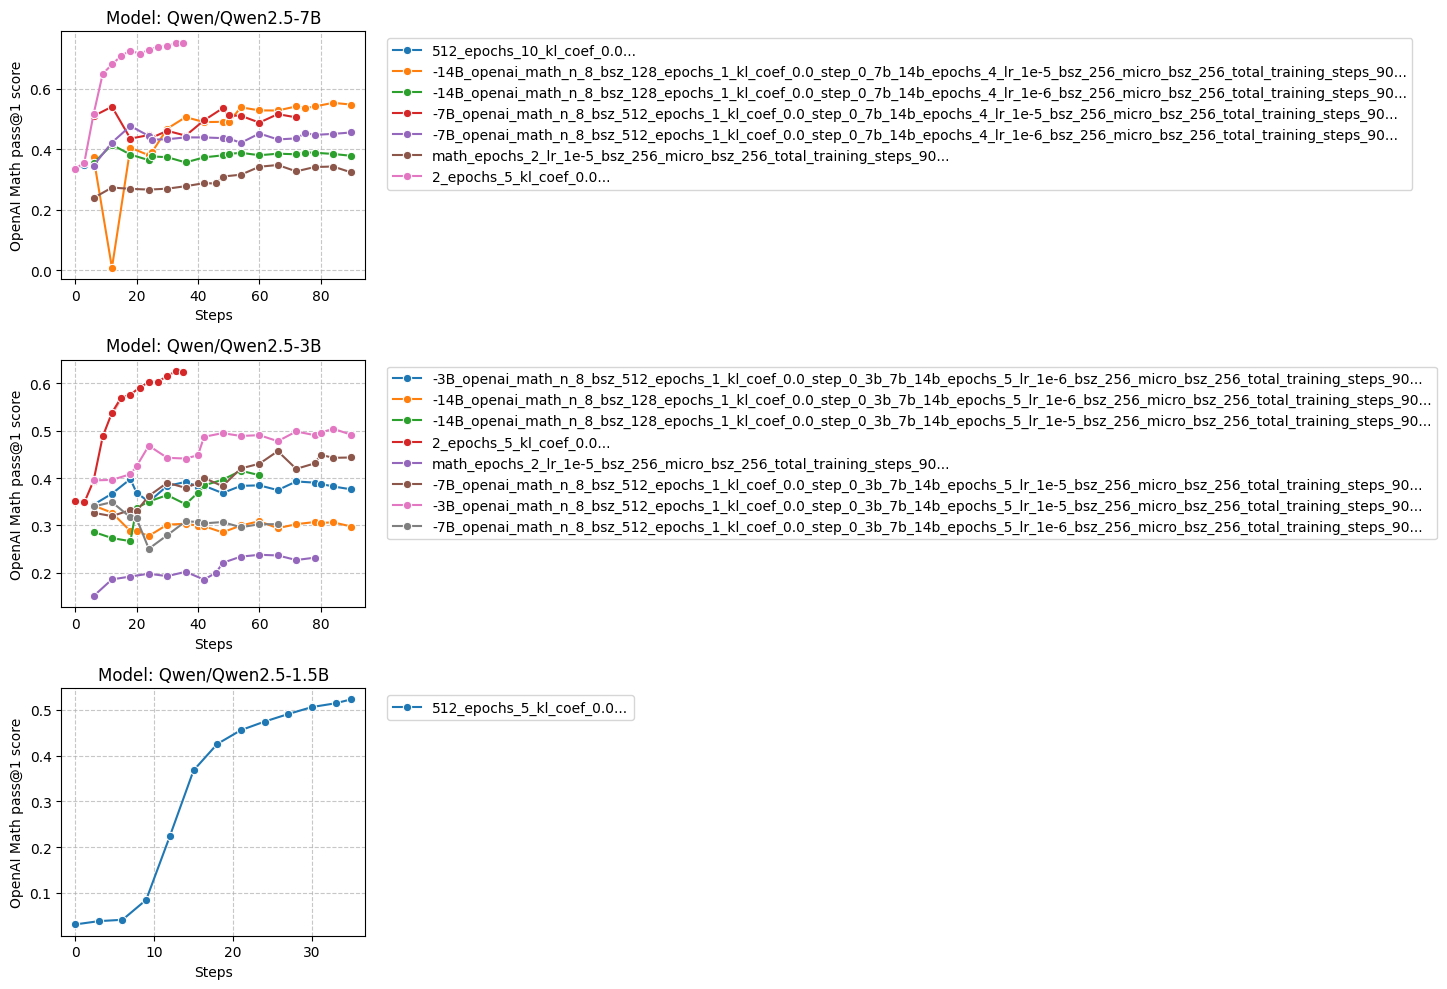

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get experiment names that have more than one step/row
exp_counts = results.groupby('exp_name').size()
valid_exps = exp_counts[exp_counts > 1].index.tolist()

# Filter results to only include experiments with multiple steps
filtered_results = results[results['exp_name'].isin(valid_exps)]

# Get unique models
unique_models = filtered_results['model'].unique()

# Set up the figure
plt.figure(figsize=(15, 10))

# Create a plot for each model
for i, model in enumerate(unique_models):
    model_data = filtered_results[filtered_results['model'] == model]
    
    # Skip if no data for this model
    if len(model_data) == 0:
        continue
    
    # Get unique experiment names for this model
    exp_names = model_data['exp_name'].unique()
    
    # Create subplot
    plt.subplot(len(unique_models), 1, i+1)
    
    # Plot each experiment as a separate line
    for exp_name in exp_names:
        exp_data = model_data[model_data['exp_name'] == exp_name]
        
        # Only plot if there are multiple steps for this experiment
        if len(exp_data) > 1:
            sns.lineplot(
                data=exp_data, 
                x='step', 
                y='val/simplescaling/openaimath/pass@1/mean@8',
                label=exp_name[33:] + '...' if len(exp_name) > 30 else exp_name,
                marker='o'
            )
    
    plt.title(f'Model: {model}')
    plt.xlabel('Steps')
    plt.ylabel('OpenAI Math pass@1 score')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()



In [21]:
dapo = pd.read_parquet('/fast/pmayilvahanan/datasets/dapo_math_17k/train.parquet')

In [23]:
dapo['prompt'][0]

array([{'content': 'Solve the following math problem step by step. The last line of your response should be of the form Answer: $Answer (without quotes) where $Answer is the answer to the problem.\n\nIn triangle $ABC$, $\\sin \\angle A = \\frac{4}{5}$ and $\\angle A < 90^\\circ$. Let $D$ be a point outside triangle $ABC$ such that $\\angle BAD = \\angle DAC$ and $\\angle BDC = 90^\\circ$. Suppose that $AD = 1$ and that $\\frac{BD}{CD} = \\frac{3}{2}$. If $AB + AC$ can be expressed in the form $\\frac{a\\sqrt{b}}{c}$ where $a, b, c$ are pairwise relatively prime integers, find $a + b + c$.\n\nRemember to put your answer on its own line after "Answer:".', 'role': 'user'}],
      dtype=object)